# US Firm Characteristics: Backtest and Equal-Weight Baseline

**Chapter 16 - Strategy Simulation**

The US firm characteristics case study is the academic benchmark for
cross-sectional prediction: a wide monthly panel of US stocks described by
anomaly characteristics. Every model notebook before this one wrote its
validation predictions to the run log. This notebook turns each of those
prediction sets into long-short, equal-weight strategies - one per entry
scheme - and registers what each earned. The sealed holdout is not read here.

An **entry scheme** is how a ranking becomes a position: take the top *k*
names long and the bottom *k* short, equally weighted. Sweeping several values
of *k* over the same predictions separates how well a model ranks from how
concentrated a portfolio built on that ranking has to be before the ranking
pays.

Three steps:

1. **Plumbing test** - check that a random ranking earns nothing through the
   same code path, so a positive result later is not an artefact of the engine
2. **Parametric sweep** - every prediction set against every entry scheme
3. **Baseline surface** - read back what the sweep registered

Sections 1–2 write to the registry. Section 3 is read-only: it queries the
registry through `BacktestExplorer` and can be re-run without re-running the
sweep.

**Book Reference:** Chapter 16, Sections 16.4–16.8

**Prerequisites:** Completed model training (Ch11–15) for this case study.

In [1]:
"""Ch16 backtest and equal-weight baseline for US Firm Characteristics."""

import time
from collections import Counter
from itertools import cycle

import polars as pl

from utils.style import COLORS, add_message_title, apply_ml4t_style, show_with_alt

apply_ml4t_style()

from case_studies.research import open_study, reuse_disclosure
from case_studies.utils.backtest_loaders import get_backtest_config, load_backtest_prices_for
from case_studies.utils.backtest_presets import (
    build_backtest_spec,
    serializable_backtest_spec,
    traded_universe_declaration,
)
from case_studies.utils.backtest_runner import (
    normalize_prediction_columns,
    run_backtest,
    run_plumbing_test,
)
from case_studies.utils.registry import (
    backtest_hash_from_parts,
    load_existing_backtest_hashes,
    load_prediction_index,
    read_predictions,
)
from case_studies.utils.sweep_config import get_entry_schemes_for, get_top_n_predictions
from utils.paths import get_case_study_dir

In [2]:
CASE_STUDY_ID = "us_firm_characteristics"
LABEL = ""
SPLIT = "validation"
TOP_K = 20
# Reduces the price panel and nothing else. The vectorized backtest computes its
# return as weight x y_true from the predictions frame, so the universe and the
# P&L both come from the predictions rather than from these prices; what the price
# panel supplies is the rebalance calendar, and that is the same 110 month-ends
# whichever symbols are in it. Measured on this notebook: 300 symbols and the full
# 3,708 give bit-identical Sharpe, CAGR and drawdown on all 32 backtests of an
# 8-prediction sweep, in 21 s against 19 s. It is kept because the fleet's
# notebooks share this parameter, but it does not reduce a run here.
# TOP_N_PREDICTIONS is the knob that does.
MAX_SYMBOLS = 0
FORCE_REBACKTEST = False  # Set True to re-backtest even if a complete backtest_hash exists
TOP_N_PREDICTIONS = None
# How far a no-edge Sharpe may land from zero before the plumbing test is read as a
# failure of the engine rather than as sampling noise. The whole fleet uses 1.5.
PLUMBING_SHARPE_TOLERANCE = 1.5
# Both names stay bound here although nothing below reads them: that is what makes the harness
# force preview and supply a workspace - `_declares_tier_and_workspace` in `tests/pm_helpers.py`
# looks for exactly this pair. Without them the canonical branch regenerates in place, which
# needs symlinks a CI checkout does not have.
EXECUTION_TIER = "canonical"
WORKSPACE: str = ""

The study is opened before anything resolves a path or reads the registry. Under the preview
tier, opening it activates a workspace and rewrites `ML4T_OUTPUT_DIR` process-wide, and every
later `get_case_study_dir` call resolves against that. A `CASE_DIR`, a prediction index or a
`BacktestExplorer` built first would address the released registry while the sweep writes to
the preview one, and the two never meet.

In [3]:
study = open_study(CASE_STUDY_ID, execution_tier=EXECUTION_TIER, workspace=WORKSPACE or None)

## 1. Setup & Plumbing Test

A backtest engine can manufacture a return that no strategy earned - by
filling at a price the strategy could not have traded at, by ranking on a
column that already knows the outcome, or by compounding a position it never
held. None of those show up as an error. They show up as a good Sharpe.

The test that separates them is to send a signal carrying no information
through the same code path. The observed validation prices stay fixed, the
model scores are replaced by seeded random rankings, and the result goes
through the same vectorized backtest the model predictions will use. A random
ranking has no edge, so anything it earns came from the engine.

It will not be exactly zero. A finite sample of months gives a Sharpe
scattered around zero even with no edge, so the check is against a tolerance
rather than against zero, and the tolerance is printed with the result.

In [4]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
bt_config = get_backtest_config(CASE_STUDY_ID)
if TOP_N_PREDICTIONS is None:
    TOP_N_PREDICTIONS = get_top_n_predictions(CASE_STUDY_ID, "signal")

if not LABEL:
    LABEL = bt_config.primary_label

print(f"""=== Protocol Term Sheet ===
  Case study:    {CASE_STUDY_ID}
  Label:         {LABEL}
  Calendar:      {bt_config.calendar}
  Cadence:       {bt_config.cadence}
  Commission:    {bt_config.commission_bps:.1f} bps
  Slippage:      {bt_config.slippage_bps:.1f} bps
  Total cost:    {bt_config.commission_bps + bt_config.slippage_bps:.1f} bps/leg
  Long/short:    {bt_config.long_short}
""")

=== Protocol Term Sheet ===
  Case study:    us_firm_characteristics
  Label:         fwd_ret_1m
  Calendar:      None
  Cadence:       monthly_month_end
  Commission:    7.5 bps
  Slippage:      5.0 bps
  Total cost:    12.5 bps/leg
  Long/short:    True



In [5]:
prices = load_backtest_prices_for(CASE_STUDY_ID, LABEL, split="validation", max_symbols=MAX_SYMBOLS)

# `MAX_SYMBOLS` reduces the price panel, and until the run says so in its own specification
# that reduction did not reach `backtest_hash`: a reduced run and the full run over the same
# predictions hashed alike, so the second was served the first's result and the reduction
# bought nothing (ml4t/agent-workspace#911). Declaring it here, before anything is hashed,
# gives a reduced run an identity of its own; `run_backtest` checks the panel against the
# declaration and narrows the predictions to it, so the sweep ranks the cross-section this
# says it ranks and `n_assets` above describes that same set. A full run declares nothing and
# is byte-identical to before.
# A reduced run is a preview run. Refused on the canonical tier so a narrowed result can
# never land in the registry the book's numbers come from, and so the two can never sit in
# one registry to be ranked against each other: `resolve_best_predictions` takes MAX(sharpe)
# over every backtest of a prediction, and a Sharpe earned over a handful of names would
# advance a configuration ahead of one earned over the whole panel. `us_equities_panel` 16
# through 19 already refuse the parameter this way, and `canonically_refused_parameters`
# reads the refusal out of the source, so the canonical fixture path drops the name rather
# than handing the notebook something its first cell raises on.
if EXECUTION_TIER == "canonical" and MAX_SYMBOLS:
    raise ValueError(
        "MAX_SYMBOLS narrows the universe this run trades, which makes it a different "
        "portfolio from the declared one and gives it its own backtest identity "
        "(ml4t/agent-workspace#911). A canonical run trades the declared universe: set "
        "MAX_SYMBOLS=0, or run under EXECUTION_TIER='preview' with a WORKSPACE."
    )
TRADED_UNIVERSE = traded_universe_declaration(prices) if MAX_SYMBOLS else None

n_assets = prices["symbol"].n_unique()
print(f"Prices: {len(prices):,} rows, {n_assets} assets")

pred_index = load_prediction_index(
    CASE_STUDY_ID,
    label=LABEL,
    split=SPLIT,
)
if pred_index.is_empty():
    msg = f"No predictions found for {CASE_STUDY_ID}/{LABEL}/{SPLIT}"
    raise RuntimeError(msg)

plumbing_predictions = normalize_prediction_columns(
    read_predictions(CASE_STUDY_ID, pred_index["prediction_hash"][0])
)

Prices: 252,008 rows, 3708 assets


In [6]:
strategy_spec = build_backtest_spec(
    CASE_STUDY_ID,
    bt_config,
    prices=prices,
    traded_universe=TRADED_UNIVERSE,
    prediction_hash="plumbing_test",
    initial_cash=bt_config.initial_cash,
    chapter="ch16",
    label=LABEL,
    signal={
        "method": "score_weighted_top_k",
        "top_k": TOP_K,
        "long_short": bt_config.long_short,
    },
)

try:
    random_sharpe = run_plumbing_test(
        CASE_STUDY_ID,
        prices,
        strategy_spec,
        predictions=plumbing_predictions,
        label=LABEL,
        top_k=TOP_K,
        initial_cash=bt_config.initial_cash,
        calendar=bt_config.calendar,
    )

    status = "PASS" if abs(random_sharpe) < PLUMBING_SHARPE_TOLERANCE else "FAIL"
    print(f"Random signal Sharpe: {random_sharpe:.3f}  [{status}]")
    print(f"Tolerance: |Sharpe| < {PLUMBING_SHARPE_TOLERANCE}")

    if status == "FAIL":
        print("WARNING: Random signal produces non-trivial Sharpe - investigate pipeline")
except ValueError as e:
    if "zero variance" in str(e).lower():
        print(f"Plumbing test skipped: {e} (too few assets for meaningful test)")
        random_sharpe = 0.0
    else:
        raise

Random signal Sharpe: -0.149  [PASS]
Tolerance: |Sharpe| < 1.5


## 2. Parametric Sweep

Sweep all prediction and entry-scheme combinations using the **same
`run_backtest()` function** as a single backtest. The sweep is pure
orchestration, not a separate implementation.

The prediction index is printed below by family, so the surface being swept is
visible before it is swept. Causal DML estimates a treatment effect in a separate
registry table and produces no trading predictions, so it is absent by
construction rather than by omission. This notebook evaluates the primary label
only; the other labels are separate runs rather than hidden dimensions of this
surface.

In [7]:
if TOP_N_PREDICTIONS > 0:
    pred_index = pred_index.head(TOP_N_PREDICTIONS)

n_predictions = len(pred_index)
print(f"Predictions to sweep: {n_predictions}")
print(pred_index.group_by("family").len().sort("family"))
ic_min, ic_max = pred_index["ic_mean"].min(), pred_index["ic_mean"].max()
if ic_min is not None:
    print(f"  IC range: {ic_min:.4f} to {ic_max:.4f}")
else:
    print("  IC range: not yet computed")

Predictions to sweep: 228
shape: (4, 2)
┌────────────────┬─────┐
│ family         ┆ len │
│ ---            ┆ --- │
│ str            ┆ u32 │
╞════════════════╪═════╡
│ gbm            ┆ 150 │
│ latent_factors ┆ 26  │
│ linear         ┆ 28  │
│ tabular_dl     ┆ 24  │
└────────────────┴─────┘
  IC range: -0.0517 to 0.0836


In [8]:
entry_schemes = get_entry_schemes_for(
    CASE_STUDY_ID, LABEL, n_assets, long_short=bt_config.long_short
)
n_schemes = len(entry_schemes)

print(f"\nEntry schemes ({n_schemes}):")
for es in entry_schemes:
    print(f"  {es['name']}: {es['method']} (top_k={es.get('top_k', '-')})")

total_backtests = n_predictions * n_schemes
print(
    f"\nTotal grid: {n_predictions} predictions x {n_schemes} schemes = {total_backtests} backtests"
)

# A grid with no schemes is a configuration error, not a result, and it is silent at the
# point it happens: `get_entry_schemes_for` drops each declared k that the cross-section
# cannot realize and returns the empty list, so the sweep below completes in zero seconds
# reporting zero failures, and every section after it reads a registry this run never wrote
# to. Refuse here, where the numbers that explain it are still in hand, rather than several
# cells later on whatever the first empty read happens to raise
# (ml4t/agent-workspace#1075).
if n_schemes == 0:
    raise RuntimeError(
        f"No entry scheme in backtest.sweep.top_k_grid[{LABEL!r}] is feasible on "
        f"{n_assets} assets. A scheme needs k < n_assets, because k == n_assets is the "
        f"whole universe and that is the equal-weight benchmark rather than a "
        f"prediction-based portfolio; long-short additionally needs 2k <= n_assets so the "
        f"two legs stay disjoint. Widen the universe (MAX_SYMBOLS) or declare a smaller k."
    )


Entry schemes (4):
  ew_top5: equal_weight_top_k (top_k=5)
  ew_top10: equal_weight_top_k (top_k=10)
  ew_top20: equal_weight_top_k (top_k=20)
  ew_top50: equal_weight_top_k (top_k=50)

Total grid: 228 predictions x 4 schemes = 912 backtests


In [9]:
results = []
failures: Counter[str] = Counter()
t0 = time.time()
failed = 0
skipped = 0
completed_attempts = 0
existing_hashes = load_existing_backtest_hashes(CASE_STUDY_ID, stage="signal")
print(f"Existing equal-weight baseline hashes in registry: {len(existing_hashes):,}")

for pred_row in pred_index.iter_rows(named=True):
    pred_hash = pred_row["prediction_hash"]
    source = pred_row["source"]
    ic_mean = pred_row["ic_mean"]

    pending_schemes = []

    for scheme in entry_schemes:
        signal = {
            "method": scheme["method"],
            "top_k": scheme.get("top_k", 20),
            "long_short": bt_config.long_short,
        }
        signal.update({k: v for k, v in scheme.items() if k not in ("name", "method")})
        spec = build_backtest_spec(
            CASE_STUDY_ID,
            bt_config,
            prices=prices,
            traded_universe=TRADED_UNIVERSE,
            prediction_hash=pred_hash,
            initial_cash=bt_config.initial_cash,
            chapter="ch16",
            # The step this label declares is part of the backtest identity, and it reaches
            # the spec only through `label=`. Without it the hash below is one no run
            # registers, so every one of the registry's baseline rows reads as missing and
            # the sweep recomputes all of them (ml4t/agent-workspace#1028).
            label=LABEL,
            signal=signal,
        )
        backtest_hash = backtest_hash_from_parts(pred_hash, serializable_backtest_spec(spec))
        if backtest_hash in existing_hashes:
            skipped += 1
            completed_attempts += 1
            if completed_attempts % 20 == 0 or completed_attempts == total_backtests:
                elapsed = time.time() - t0
                rate = completed_attempts / elapsed if elapsed > 0 else 0
                print(
                    f"  [{completed_attempts}/{total_backtests}] {elapsed:.0f}s "
                    f"({rate:.1f} bt/s) | failed: {failed}"
                )
            continue
        pending_schemes.append((scheme, spec))

    if not pending_schemes:
        continue

    predictions = normalize_prediction_columns(read_predictions(CASE_STUDY_ID, pred_hash))

    for scheme, spec in pending_schemes:
        try:
            result = run_backtest(
                CASE_STUDY_ID,
                pred_hash,
                spec,
                prices=prices,
                predictions=predictions,
                label=LABEL,
                register=True,
                force_rebacktest=FORCE_REBACKTEST,
                initial_cash=bt_config.initial_cash,
                calendar=bt_config.calendar,
            )

            results.append(
                {
                    "prediction_hash": pred_hash,
                    "source": source,
                    "ic_mean": ic_mean,
                    "family": pred_row["family"],
                    "config_name": pred_row["config_name"],
                    "signal_method": scheme["name"],
                    "backtest_hash": result.backtest_hash,
                    "sharpe": result.metrics["sharpe"],
                    "total_return": result.metrics["total_return"],
                    "max_drawdown": result.metrics["max_drawdown"],
                    "cagr": result.metrics.get("cagr", 0.0),
                    "volatility": result.metrics.get("volatility", 0.0),
                    "num_trades": result.metrics.get("num_trades", 0),
                    "error": None,
                }
            )
            if result.backtest_hash:
                existing_hashes.add(result.backtest_hash)
        except Exception as error:
            # A backtest that raises is recorded, not lost. Every reason is kept and
            # counted below: a sweep in which all of them fail otherwise prints a
            # completion line and a failure count, and section 3 then reads a registry
            # the sweep never wrote to, with nothing in the notebook saying why.
            failed += 1
            failures[f"{type(error).__name__}: {error}"] += 1
            results.append(
                {
                    "prediction_hash": pred_hash,
                    "source": source,
                    "ic_mean": ic_mean,
                    "family": pred_row["family"],
                    "config_name": pred_row["config_name"],
                    "signal_method": scheme["name"],
                    "backtest_hash": None,
                    "sharpe": None,
                    "total_return": None,
                    "max_drawdown": None,
                    "cagr": None,
                    "volatility": None,
                    "num_trades": None,
                    "error": f"{type(error).__name__}: {error}",
                }
            )

        completed_attempts += 1
        if completed_attempts % 20 == 0 or completed_attempts == total_backtests:
            elapsed = time.time() - t0
            rate = completed_attempts / elapsed if elapsed > 0 else 0
            print(
                f"  [{completed_attempts}/{total_backtests}] {elapsed:.0f}s "
                f"({rate:.1f} bt/s) | failed: {failed}"
            )

elapsed = time.time() - t0
print(f"\nSweep complete in {elapsed:.0f}s: {reuse_disclosure(len(results), skipped, failed)}")
for reason, count in failures.most_common():
    print(f"  {count:>5} x {reason[:150]}")

Existing equal-weight baseline hashes in registry: 2,276


  [20/912] 43s (0.5 bt/s) | failed: 0


  [40/912] 89s (0.4 bt/s) | failed: 0


  [60/912] 132s (0.5 bt/s) | failed: 0


  [80/912] 172s (0.5 bt/s) | failed: 0


...

  [840/912] 1079s (0.8 bt/s) | failed: 0


  [860/912] 1100s (0.8 bt/s) | failed: 0


  [880/912] 1120s (0.8 bt/s) | failed: 0


  [900/912] 1144s (0.8 bt/s) | failed: 0


  [912/912] 1155s (0.8 bt/s) | failed: 0

Sweep complete in 1155s: computed all 912


## 3. Equal-Weight Baseline Evaluation

This section is **read-only**: it queries the registry via `BacktestExplorer`
and does not depend on the sweep having just run. You can re-run this section
at any time to analyze existing results.

Two questions the sweep can answer: whether the predictions translate into
positive validation Sharpe at all, and how tightly a model's rank correlation with
the outcome maps onto what a portfolio built from that ranking earned.

The second is worth watching, and it has to be asked *within* a family rather than
across all of them at once. Families sit at different levels on both axes, so
pooling them produces a positive correlation out of that separation alone, whether
or not IC and Sharpe move together inside any one family. This is why the scatter
below is coloured: the pooled cloud and the coloured groups can say opposite
things, and only the coloured version answers the question that was asked.

In [10]:
from case_studies.utils.backtest_explorer import BacktestExplorer

explorer = BacktestExplorer(CASE_STUDY_ID)
print(repr(explorer))

BacktestExplorer('us_firm_characteristics', 3451 runs: allocation=240, cost_sensitivity=22, holdout=1, signal=3188)


### The upper tail of the surface

The ten strongest solvent runs after each configuration is capped to two slots, with
the model that produced each and how many names a side it was traded at. It is not
simply the ten highest Sharpes: a configuration's later checkpoints are near-copies of
its best, and uncapped they arrive together and fill the table. Read this as the shape
of the tail rather than as a selection: these are among the largest draws from a
sweep of hundreds, so the largest is biased upward by however many were tried.
The deflated Sharpe below is the first correction for that, and the strategy
analysis notebook is where the selection is confronted properly. These are already
net of the commission and slippage `setup.yaml` declares, charged on turnover at
each rebalance; what has not been applied is portfolio construction, any cost
assumption other than that one, and a risk overlay. The next three notebooks add
those in turn.

In [11]:
# A long-short book can lose more than its capital in one period: the long leg cannot
# fall past -100%, but the short leg's loss is unbounded, and a squeeze on a
# concentrated short costs more than the account holds. The engine has no margin call,
# so equity compounds straight through zero and every later period is arithmetic on a
# negative balance - which inverts the sign of gains and losses and makes the reported
# Sharpe meaningless rather than merely bad. `max_drawdown` reaching -100% is exactly
# that condition: the trough is at or past zero, so the ratio to the peak reaches -1.
# The boundary counts as ruin - equity of exactly zero earns nothing afterwards - which
# is the convention notebook 12 applies to the allocation stage.
all_runs = explorer.best(stage="signal", top_n=9999)
ruined = all_runs.filter(pl.col("max_drawdown") <= -1.0)
print(f"runs whose equity reached zero or went negative: {ruined.height} of {all_runs.height}")
if ruined.height:
    print(
        "their reported Sharpe ranges "
        f"{ruined['sharpe'].min():.2f} to {ruined['sharpe'].max():.2f}, computed on periods "
        "with no capital left to earn a return"
    )

# At most this many slots for any one model configuration. A configuration publishes a
# prediction set per checkpoint, and those checkpoints are near-copies of each other:
# ranked on Sharpe alone they arrive together, so the strongest configuration takes the
# table and the reader sees one model's checkpoints where they were promised the best of
# the sweep. Before this cap, `gbm/leaves_7_mse` held eight of ten slots and two
# configurations held all ten - no other family appeared at all.
MAX_SLOTS_PER_CONFIG = 2

# Ranked among the solvent runs only. An insolvent path still carries a Sharpe, and
# on a negative balance it can exceed every strategy that held its capital - so
# ranking the full set would let the table name one of them best. `all_runs` is
# already ordered by Sharpe descending, so a running count within each source keeps
# each configuration's best few and drops the rest. The figures below filter on
# solvency identically; they are distributions over every run, so the cap is not
# theirs to apply.
top = (
    all_runs.filter(pl.col("max_drawdown") > -1.0)
    .with_columns(slot=pl.int_range(pl.len()).over("source"))
    .filter(pl.col("slot") < MAX_SLOTS_PER_CONFIG)
    .drop("slot")
    .head(10)
)

# `best` reports `signal.method`, which is the same string for every entry scheme in
# this sweep, so on its own the table cannot tell a five-name portfolio from a fifty-
# name one - the dimension the sweep exists to vary. The concentration is in the same
# spec, one key across, and is joined back here.
concentration = (
    explorer.specs("signal")
    .drop("stage")
    .with_columns(
        names_per_side=pl.col("spec_json")
        .str.json_path_match("$.strategy.signal.top_k")
        .cast(pl.Int64)
    )
    .drop("spec_json")
)

top = top.join(concentration, on="backtest_hash", how="left")
print(top.select("source", "names_per_side", "sharpe", "cagr", "max_drawdown"))
_families = top["family"].n_unique()
_other_best = all_runs.filter(
    (pl.col("max_drawdown") > -1.0) & (pl.col("family") != top["family"][0])
)["sharpe"].max()
print(
    f"At most {MAX_SLOTS_PER_CONFIG} slots per configuration: "
    f"{top['source'].n_unique()} configurations, {_families} "
    f"{'family' if _families == 1 else 'families'}."
)
# The cap separates two things that look alike in a ranked table. One configuration's
# checkpoints filling it is an artefact of ranking near-copies; one family filling it can
# be a result. Which this is, is checkable rather than asserted: print the best solvent
# run outside the leading family beside the table's weakest entry.
print(
    f"{top['family'][0]} fills the table on merit - its weakest entry here is "
    f"{top['sharpe'].min():.3f} and the best solvent run of any other family is "
    f"{_other_best:.3f}."
)

runs whose equity reached zero or went negative: 32 of 3166
their reported Sharpe ranges -0.24 to 1.43, computed on periods with no capital left to earn a return
shape: (10, 5)
┌─────────────────────┬────────────────┬──────────┬──────────┬──────────────┐
│ source              ┆ names_per_side ┆ sharpe   ┆ cagr     ┆ max_drawdown │
│ ---                 ┆ ---            ┆ ---      ┆ ---      ┆ ---          │
│ str                 ┆ i64            ┆ f64      ┆ f64      ┆ f64          │
╞═════════════════════╪════════════════╪══════════╪══════════╪══════════════╡
│ gbm/leaves_31_huber ┆ 20             ┆ 3.557338 ┆ 1.101224 ┆ -0.179363    │
│ gbm/leaves_31_huber ┆ 20             ┆ 3.522249 ┆ 1.151156 ┆ -0.239024    │
│ gbm/leaves_63_huber ┆ 20             ┆ 3.337334 ┆ 1.027444 ┆ -0.185935    │
│ gbm/leaves_7_huber  ┆ 10             ┆ 3.29904  ┆ 1.49071  ┆ -0.139173    │
│ gbm/leaves_15_mae   ┆ 20             ┆ 3.298066 ┆ 1.159803 ┆ -0.177138    │
│ gbm/leaves_15_mae   ┆ 20             ┆ 3.

### By model family

Grouping by family asks a different question from the table above: not which
single configuration landed highest, but whether a family's strategies were
generally worth trading. A family with one large Sharpe and a median near zero
produced one lucky draw; a family whose median is well above zero produced a
signal. The maximum is the statistic the sweep size inflates, and the median is
the one it does not.

The label is held fixed across every row, so what separates the families here
is the model and its checkpoint, not the target they were fitted to.

The Sharpe columns are computed over the runs that stayed solvent, `insolvent` counts
the runs of that family that reached zero, and `unknown` those with no drawdown
recorded, which are held out of the statistics without being called failures. All
three are needed to read the table: the statistics would be meaningless with the
ruined runs in them, and dropping those runs without counting them would rank a
family by its survivors, so a family that went to zero in most of its runs would show
the Sharpe of the few that did not. Read a median as conditional on the counts beside
it.

In [12]:
families = explorer.compare_families(stage="signal", exclude_insolvent=True)
print(families)
print(
    f"Sharpe statistics are computed over solvent runs only; `insolvent` and `unknown` "
    f"count the rest. Across all families, {ruined.height:,} of {all_runs.height:,} "
    f"registered signal-stage runs reached zero or went past it."
)

shape: (4, 8)
┌──────────────┬──────┬───────────┬─────────┬──────────────┬────────────┬────────────┬─────────────┐
│ family       ┆ n    ┆ insolvent ┆ unknown ┆ sharpe_media ┆ sharpe_max ┆ sharpe_q75 ┆ pct_positiv │
│ ---          ┆ ---  ┆ ---       ┆ ---     ┆ n            ┆ ---        ┆ ---        ┆ e           │
│ str          ┆ u32  ┆ u32       ┆ u32     ┆ ---          ┆ f64        ┆ f64        ┆ ---         │
│              ┆      ┆           ┆         ┆ f64          ┆            ┆            ┆ f64         │
╞══════════════╪══════╪═══════════╪═════════╪══════════════╪════════════╪════════════╪═════════════╡
│ gbm          ┆ 1970 ┆ 30        ┆ 0       ┆ 1.80604      ┆ 3.557338   ┆ 2.310584   ┆ 100.0       │
│ tabular_dl   ┆ 360  ┆ 24        ┆ 0       ┆ 0.907592     ┆ 2.070597   ┆ 1.128172   ┆ 100.0       │
│ linear       ┆ 388  ┆ 0         ┆ 0       ┆ 0.717724     ┆ 1.87069    ┆ 0.969127   ┆ 98.969072   │
│ latent_facto ┆ 416  ┆ 0         ┆ 0       ┆ 0.634873     ┆ 1.72935    ┆ 0.8

Strategies plotted: 3,134 | dropped for no computed IC: 0 | excluded as insolvent: 32


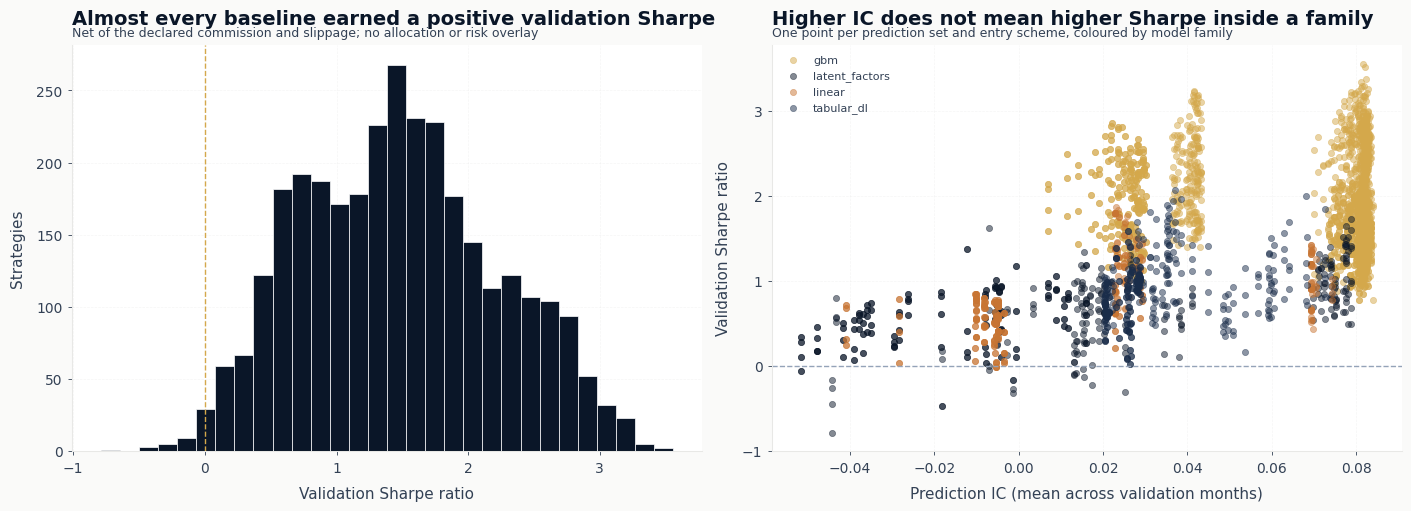

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Solvent runs only. A path that went bankrupt still has a Sharpe and an IC, and
# plotting them puts a number with no meaning into the distribution the reader is
# asked to read a conclusion off.
all_signal = explorer.best(stage="signal", top_n=9999).filter(pl.col("max_drawdown") > -1.0)
if not all_signal.is_empty():
    axes[0].hist(all_signal["sharpe"].to_numpy(), bins=30, color=COLORS["blue"], edgecolor="white")
    axes[0].axvline(0, color=COLORS["amber"], linestyle="--", linewidth=1)
    axes[0].set_xlabel("Validation Sharpe ratio")
    axes[0].set_ylabel("Strategies")
    add_message_title(
        axes[0],
        "Almost every baseline earned a positive validation Sharpe",
        subtitle="Net of the declared commission and slippage; no allocation or risk overlay",
    )

    # A prediction whose IC was never computed has no position on this axis. Filling
    # it with zero would place it at a value it does not hold, stacking a column of
    # unmeasured predictions on the origin and flattening whatever relationship the
    # measured ones show. Drop them and say how many.
    scored = all_signal.filter(pl.col("ic_mean").is_not_null())
    unscored = all_signal.height - scored.height
    # Colour by family, because the question this panel is under is whether ranking
    # skill and portfolio return move together, and family is what separates the
    # groups being compared. An uncoloured cloud cannot answer it.
    # Cycled rather than indexed: a fifth family added upstream would otherwise be
    # dropped from the plot without anything saying so.
    palette = cycle([COLORS["amber"], COLORS["blue"], COLORS["copper"], COLORS["slate"]])
    for colour, (family,) in zip(palette, sorted(scored.select("family").unique().rows())):
        group = scored.filter(pl.col("family") == family)
        axes[1].scatter(
            group["ic_mean"].to_numpy(),
            group["sharpe"].to_numpy(),
            alpha=0.5,
            s=20,
            color=colour,
            label=family,
        )
    axes[1].axhline(0, color=COLORS["recede"], linestyle="--", linewidth=1)
    axes[1].set_xlabel("Prediction IC (mean across validation months)")
    axes[1].set_ylabel("Validation Sharpe ratio")
    axes[1].legend(frameon=False, fontsize=8)
    add_message_title(
        axes[1],
        "Higher IC does not mean higher Sharpe inside a family",
        subtitle="One point per prediction set and entry scheme, coloured by model family",
    )
    print(
        f"Strategies plotted: {scored.height:,} | dropped for no computed IC: {unscored:,} "
        f"| excluded as insolvent: {ruined.height:,}"
    )

# No tight_layout(): matplotlibrc sets `figure.constrained_layout.use: True` repo-wide,
# and calling tight_layout() over it makes matplotlib switch layout engines and say so in
# a stderr block under the figure. See ml4t/agent-workspace#1106.
show_with_alt(
    fig,
    "Two panels over the solvent baseline backtests: on the left a histogram of validation Sharpe "
    "with a dashed line at zero, on the right one point per prediction set and entry scheme "
    "placing validation Sharpe against mean prediction IC, coloured by model family.",
)

### Deflated Sharpe Ratio

The **deflated Sharpe ratio** asks how surprising an observed Sharpe is once you
know how many strategies were tried to find it. Try enough configurations against
one validation period and the largest Sharpe among them is large whether or not
any of them has an edge, so the raw number cannot be read as evidence on its own.

$$DSR = \Phi\left[\frac{(\hat{SR} - SR^*) \sqrt{T-1}}{\sqrt{1 - \hat{\gamma}_3 \hat{SR} + \frac{\hat{\gamma}_4 - 1}{4} \hat{SR}^2}}\right]$$

$\hat{SR}$ is the observed Sharpe and $T$ the number of return observations behind
it. $SR^*$ is the benchmark the deflation is against: the Sharpe the *best of N
independent tries* would be expected to reach with no edge at all, which grows with
the number of trials. $\hat{\gamma}_3$ and $\hat{\gamma}_4$ are the skew and
kurtosis of the returns, and they are in the denominator because a Sharpe estimated
from asymmetric or fat-tailed returns is less precise than the same number from
normal ones. $\Phi$ is the normal CDF, so the result reads as a probability.

Only the per-strategy half of that can be computed here. $SR^*$ depends on how many
trials the whole pipeline runs, and three notebooks of allocation, cost and risk
variants have not run yet, so the trial count is not known. This cell reports raw
Sharpe and its per-strategy uncertainty; the deflation itself, the effective trial
count and the probability of backtest overfitting are computed once in the strategy
analysis notebook, when the count is final.

In [14]:
from case_studies.utils.backtest_loaders import print_stage_dsr_summary

print_stage_dsr_summary(explorer, top_n=20, head=10)


--- DSR @ equal-weight baseline (K=20) ---
shape: (10, 22)
┌──────────────┬────────┬──────────────┬────────┬───┬────────────┬────────────┬─────────────┬──────┐
│ source       ┆ family ┆ label        ┆ sharpe ┆ … ┆ ras_leader ┆ ras_pvalue ┆ reality_che ┆ pbo  │
│ ---          ┆ ---    ┆ ---          ┆ ---    ┆   ┆ ---        ┆ ---        ┆ ck_pvalue   ┆ ---  │
│ str          ┆ str    ┆ str          ┆ f64    ┆   ┆ null       ┆ null       ┆ ---         ┆ null │
│              ┆        ┆              ┆        ┆   ┆            ┆            ┆ null        ┆      │
╞══════════════╪════════╪══════════════╪════════╪═══╪════════════╪════════════╪═════════════╪══════╡
│ gbm/leaves_3 ┆ gbm    ┆ fwd_ret_1m_w ┆ 3.5573 ┆ … ┆ null       ┆ null       ┆ null        ┆ null │
│ 1_huber      ┆        ┆ in           ┆        ┆   ┆            ┆            ┆             ┆      │
│ gbm/leaves_3 ┆ gbm    ┆ fwd_ret_1m_w ┆ 3.5222 ┆ … ┆ null       ┆ null       ┆ null        ┆ null │
│ 1_huber      ┆        ┆ in   

### Sharpe Progression Preview

The registry records one row per stage per prediction, so a prediction that has
been through allocation, costs and a risk overlay shows what each stage did to
its Sharpe. Run at this point in the sequence the progression contains only the
equal-weight baseline, which is the intended reading: the later stages have not
executed, and the notebook shows that rather than implying them.

In [15]:
if not top.is_empty():
    best_pred = top["prediction_hash"][0]
    prog = explorer.progression(best_pred)
    if not prog.is_empty():
        print(f"\nSharpe progression for the highest-Sharpe prediction ({top['source'][0]}):")
        print(prog.select("stage", "sharpe", "cagr", "max_drawdown"))


Sharpe progression for the highest-Sharpe prediction (gbm/leaves_31_huber):
shape: (3, 4)
┌──────────────────┬──────────┬──────────┬──────────────┐
│ stage            ┆ sharpe   ┆ cagr     ┆ max_drawdown │
│ ---              ┆ ---      ┆ ---      ┆ ---          │
│ str              ┆ f64      ┆ f64      ┆ f64          │
╞══════════════════╪══════════╪══════════╪══════════════╡
│ signal           ┆ 3.557338 ┆ 1.101224 ┆ -0.179363    │
│ allocation       ┆ 3.582869 ┆ 1.13827  ┆ -0.177018    │
│ cost_sensitivity ┆ 3.656049 ┆ 1.170208 ┆ -0.17385     │
└──────────────────┴──────────┴──────────┴──────────────┘


## What this notebook establishes, and what it does not

The plumbing test is the only claim here that stands on its own. A ranking
carrying no information went through the same code path the model predictions
take, and its Sharpe is printed above against the tolerance it is read against.
That is what licenses reading any later Sharpe as coming from the predictions
rather than from the engine.

Everything else is a surface, not a result. Every prediction set was traded at
every concentration and the outcome registered, which is what the later notebooks
read. Two properties of that surface are worth carrying forward. It is a cohort:
hundreds of configurations were tried against one validation period, so the largest
Sharpe in it is the largest of many draws and is biased upward by the count. And it
is a baseline in a specific sense - the declared commission and slippage are
charged, but every position is weighted equally, only one cost assumption has been
tested, and no risk overlay is applied. Each of the next three notebooks relaxes
one of those.

The correction for the first property needs the whole funnel - the number of
trials is not known until the last stage has run - which is why the deflated
Sharpe here is per-strategy and the cohort-level statistics are left null. The
strategy analysis notebook computes them once, at the end.

**Next:** the portfolio management notebook asks what allocating across the
selected names changes relative to weighting them equally.